In [1]:
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.max_columns',None)
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
from tqdm import tqdm

In [5]:
df = pd.read_csv('../refine_input_ANM_data_231115.csv')

In [6]:
df.head()

,기준일자,장비고유구분,단속형태,설치지역,기상관측지역,기준연월,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,평균발생시각,단속건수,제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수,장비설치일자,설치경과일수,도로종류,구간유형,도로유형,도로선형
0,2020-02-01,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.4,-4.2,7.1,0.0,6.1,1.0,83.4,5.6,111008,68784,2021-01-31,-365,시도,일반구역,단일로,직선평지
1,2020-02-02,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.1,-3.1,6.5,0.0,4.0,0.9,73.3,4.7,111008,68784,2021-01-31,-364,시도,일반구역,단일로,직선평지
2,2020-02-03,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.3,-3.7,5.1,0.0,8.7,1.9,56.5,3.5,111008,68784,2021-01-31,-363,시도,일반구역,단일로,직선평지
3,2020-02-04,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,-1.2,-8.7,5.9,1.7,7.8,1.5,70.8,3.9,111008,68784,2021-01-31,-362,시도,일반구역,단일로,직선평지
4,2020-02-05,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,-6.5,-9.5,-2.0,0.0,7.7,1.8,42.9,1.6,111008,68784,2021-01-31,-361,시도,일반구역,단일로,직선평지


In [7]:
df.loc[df[df['평균초과속도']<0].index,'평균초과속도'] = 0

# 데이터셋 분할

In [ ]:
mts = pd.read_csv('../use_data/csv/230920_교통과학장비 설치정보_경기남부.csv')

mts.columns = [x.replace('*','').strip() for x in mts.columns]

match_dict = {key : value for key, value in zip(mts['장비번호'], mts['설치일자'])}

In [70]:
ttmp = mts[mts['단속형태'] =='구간과속'][['구간그룹명','설치일자']].drop_duplicates()
ttmp['구간그룹명'] = ttmp['구간그룹명'].apply(lambda x : x.split('(')[0])
sct_match_dic = {key : value for key,value in zip(ttmp['구간그룹명'],ttmp['설치일자'])}

In [83]:
lgt = df[df['단속형태'] == '신호위반']
spd = df[df['단속형태'] == '속도위반']
sct = df[df['단속형태'] == '구간과속']

In [77]:
ttmp

,구간그룹명,설치일자
66,김포 걸포동,2016-10-13
72,김포 고촌읍,2016-10-13
587,성남-장호원간,2018-12-10
593,성남-장호원간,2018-12-10
599,성남-장호원간,2018-12-10
699,시흥 도심형구간,2018-12-06
993,김포시 고촌읍 신곡리,2020-01-20
999,김포시 운양동,2020-01-20
1065,서울외곽순환고속도로,2020-03-16
1130,영동고속도로,2020-05-27


# 사고 지표 분석

In [9]:
tmp_lgt = gpd.read_file('../use_data/gis/MTS_LIGHT_SLTD_ACC_4326.shp')
tmp_spd = gpd.read_file('../use_data/gis/MTS_SPEED_SLTD_ACC_4326.shp')
#tmp_sct = gpd.read_file('../use_data/gis/MTS_SECTION_SLTD_ACC_4326.shp')

In [51]:
tmp_sct = gpd.read_file('../use_data/gis/MTS_SECTION_SLTD_ACC_4326.shp',encoding='cp949')

In [72]:
sct_match_dic['오성면구간,신대리구간'] = sct_match_dic.pop('오성면구간')

## 사고 건수 변화 추이

In [164]:
tmp_lgt['acc_date'] = tmp_lgt['DT_006'].apply(lambda x : str(x)[:8])
tmp_spd['acc_date'] = tmp_spd['DT_006'].apply(lambda x : str(x)[:8])
tmp_sct['acc_date'] = tmp_sct['DT_006'].apply(lambda x : str(x)[:8])

tmp_lgt['acc_time'] = tmp_lgt['DT_006'].apply(lambda x : str(x)[8:])
tmp_spd['acc_time'] = tmp_spd['DT_006'].apply(lambda x : str(x)[8:])
tmp_sct['acc_time'] = tmp_sct['DT_006'].apply(lambda x : str(x)[8:])

tmp_lgt['acc_weekday'] = tmp_lgt['acc_date'].apply(lambda x : datetime.strptime(x,'%Y%m%d').weekday())
tmp_spd['acc_weekday'] = tmp_spd['acc_date'].apply(lambda x : datetime.strptime(x,'%Y%m%d').weekday())
tmp_sct['acc_weekday'] = tmp_sct['acc_date'].apply(lambda x : datetime.strptime(x,'%Y%m%d').weekday())

In [74]:
tmp_lgt['설치일자'] = tmp_lgt['장비번호'].apply(lambda x : match_dict.get(x))
tmp_spd['설치일자'] = tmp_spd['장비번호'].apply(lambda x : match_dict.get(x))
tmp_sct['설치일자'] = tmp_sct['SECTION_NM'].apply(lambda x : sct_match_dic.get(x))

In [128]:
lgt_gb = lgt.groupby(['설치경과일수'], as_index=False).agg({'사고건수' : 'sum'})
lgt_gb['설치경과주'] = lgt_gb['설치경과일수'].apply(lambda x : int(x/ 7))
lgt_gb = lgt_gb.groupby(['설치경과주'],as_index=False).agg({'사고건수' : 'sum'})
lgt_gb.rename(columns = {'사고건수' : '신호_사고건수'},inplace=True)


spd_gb = spd.groupby(['설치경과일수'], as_index=False).agg({'사고건수' : 'sum'})
spd_gb['설치경과주'] = spd_gb['설치경과일수'].apply(lambda x : int(x/ 7))
spd_gb = spd_gb.groupby(['설치경과주'],as_index=False).agg({'사고건수' : 'sum'})
spd_gb.rename(columns = {'사고건수' : '과속_사고건수'},inplace=True)

sct_gb = sct.groupby(['설치경과일수'], as_index=False).agg({'사고건수' : 'sum'})
sct_gb['설치경과주'] = sct_gb['설치경과일수'].apply(lambda x : int(x/ 7))
sct_gb = sct_gb.groupby(['설치경과주'],as_index=False).agg({'사고건수' : 'sum'})
sct_gb.rename(columns = {'사고건수' : '구간_사고건수'},inplace=True)

In [129]:
tmp = pd.concat([lgt_gb,spd_gb,sct_gb],axis=1)

In [131]:
tmp.to_csv('./forvisual/acc_time.csv',index=False,encoding='cp949')

In [134]:
lgt.head()

,기준일자,장비고유구분,단속형태,설치지역,기상관측지역,기준연월,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,평균발생시각,단속건수,제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수,장비설치일자,설치경과일수,도로종류,구간유형,도로유형,도로선형
2920,2020-02-01,G6954,신호위반,군포시,수원,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.9,-2.2,7.7,0.0,8.2,1.6,91.3,6.4,275857,102045,2021-01-31,-365,국도,일반구역,교차로,직선내리막
2921,2020-02-02,G6954,신호위반,군포시,수원,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,-3.5,5.8,0.0,5.9,1.2,79.8,5.1,275857,102045,2021-01-31,-364,국도,일반구역,교차로,직선내리막
2922,2020-02-03,G6954,신호위반,군포시,수원,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,-0.1,-2.9,3.0,0.1,10.0,2.6,70.8,4.3,275857,102045,2021-01-31,-363,국도,일반구역,교차로,직선내리막
2923,2020-02-04,G6954,신호위반,군포시,수원,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,-1.0,-7.0,5.1,1.1,8.6,2.4,82.0,4.7,275857,102045,2021-01-31,-362,국도,일반구역,교차로,직선내리막
2924,2020-02-05,G6954,신호위반,군포시,수원,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,-7.2,-9.9,-2.4,0.0,11.5,3.4,58.9,2.1,275857,102045,2021-01-31,-361,국도,일반구역,교차로,직선내리막


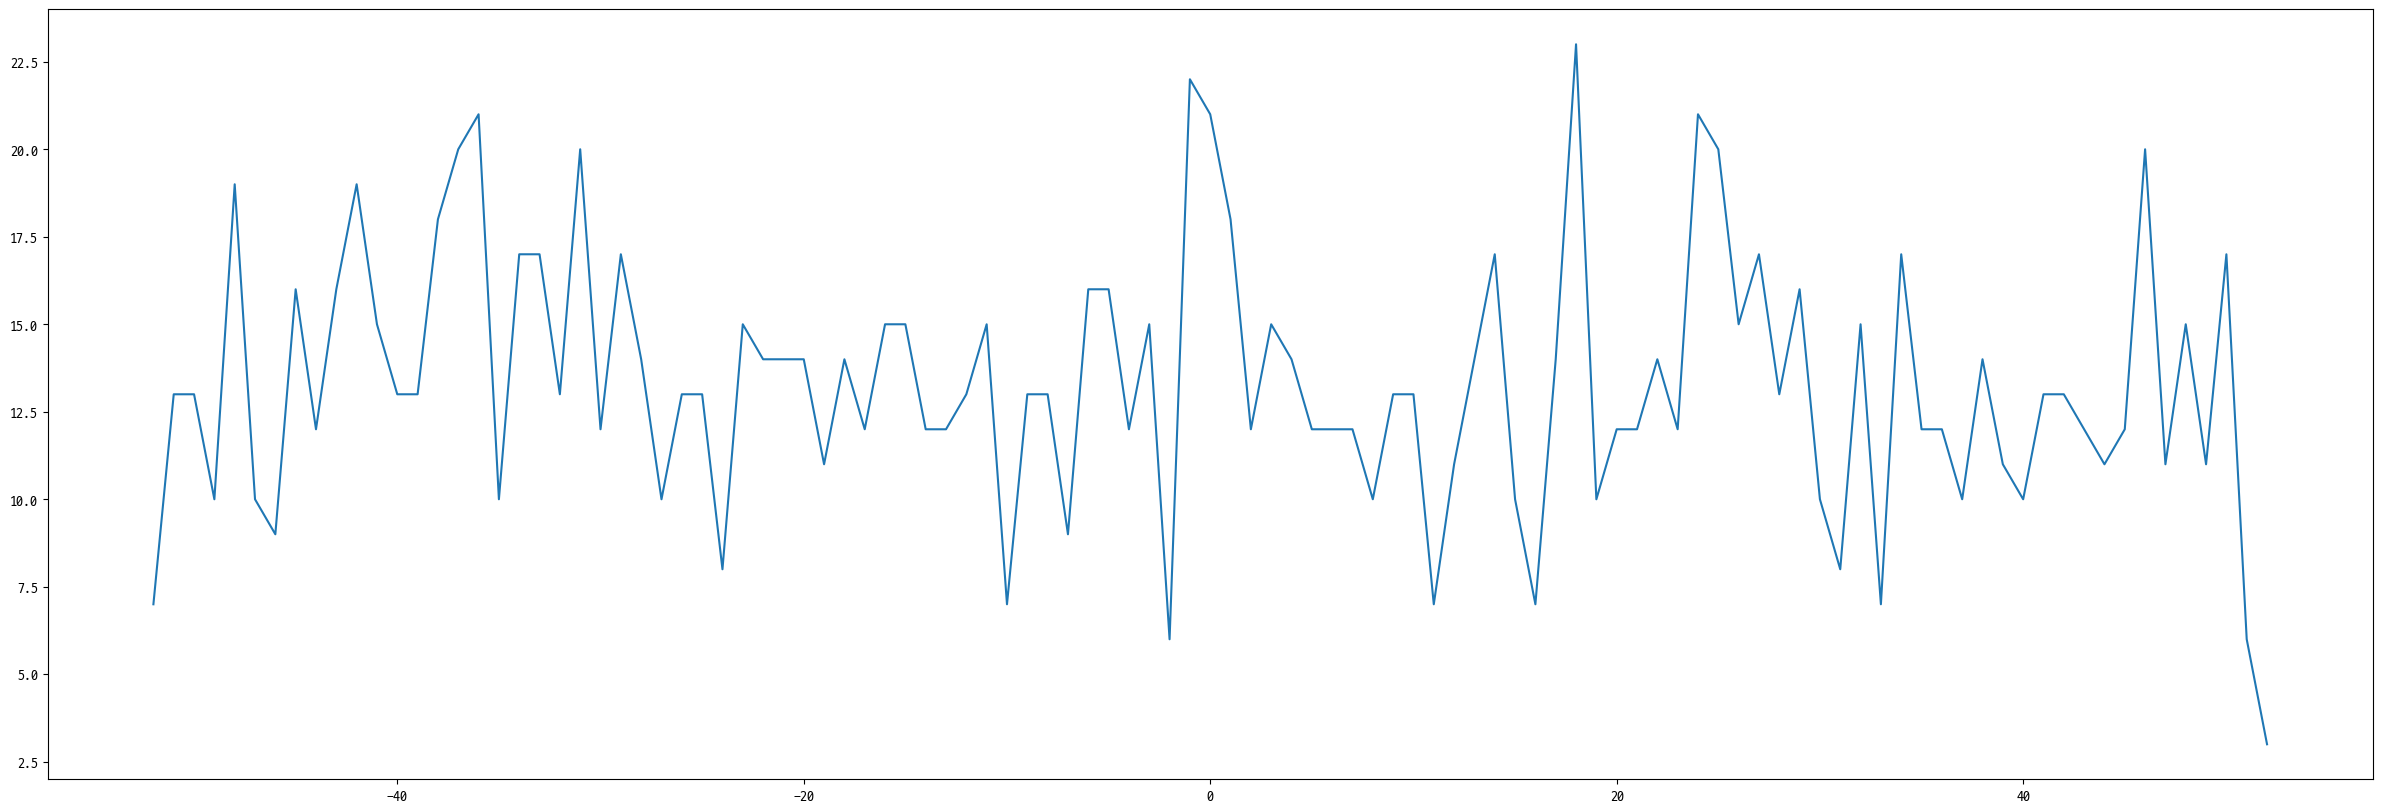

In [127]:
plt.figure(figsize=(30,10))
tmp = lgt.groupby(['설치경과일수'], as_index=False).agg({'사고건수' : 'sum'})
tmp['설치경과개월'] = tmp['설치경과일수'].apply(lambda x : int(x/ 7))
tmp = tmp.groupby(['설치경과개월'],as_index=False).agg({'사고건수' : 'sum'})
plt.plot(tmp['설치경과개월'],tmp['사고건수'])
plt.show()

In [123]:
print('신호')
print(lgt_gb[lgt_gb['설치경과주'] < 0]['신호_사고건수'].sum())
print(lgt_gb[lgt_gb['설치경과주'] >= 0]['신호_사고건수'].sum())

print('과속')
print(spd_gb[spd_gb['설치경과주'] < 0]['과속_사고건수'].sum())
print(spd_gb[spd_gb['설치경과주'] >= 0]['과속_사고건수'].sum())

print('구간')
print(sct_gb[sct_gb['설치경과주'] < 0]['구간_사고건수'].sum())
print(sct_gb[sct_gb['설치경과주'] >= 0]['구간_사고건수'].sum())

신호
713.0
687.0
과속
2144.0
2228.0
구간
133.0
131.0


## 인명 피해 변화 추이

In [135]:
lgt['인명피해수'] = lgt['사망자수'] + lgt['중상자수'] + lgt['경상자수'] + lgt['부상신고자수']
spd['인명피해수'] = spd['사망자수'] + spd['중상자수'] + spd['경상자수'] + spd['부상신고자수']
sct['인명피해수'] = sct['사망자수'] + sct['중상자수'] + sct['경상자수'] + sct['부상신고자수']

lgt_gb = lgt.groupby(['설치경과일수'], as_index=False).agg({'인명피해수' : 'sum'})
lgt_gb['설치경과주'] = lgt_gb['설치경과일수'].apply(lambda x : int(x/ 7))
lgt_gb = lgt_gb.groupby(['설치경과주'],as_index=False).agg({'인명피해수' : 'sum'})
lgt_gb.rename(columns = {'인명피해수' : '신호_인명피해수'},inplace=True)


spd_gb = spd.groupby(['설치경과일수'], as_index=False).agg({'인명피해수' : 'sum'})
spd_gb['설치경과주'] = spd_gb['설치경과일수'].apply(lambda x : int(x/ 7))
spd_gb = spd_gb.groupby(['설치경과주'],as_index=False).agg({'인명피해수' : 'sum'})
spd_gb.rename(columns = {'인명피해수' : '과속_인명피해수'},inplace=True)

sct_gb = sct.groupby(['설치경과일수'], as_index=False).agg({'인명피해수' : 'sum'})
sct_gb['설치경과주'] = sct_gb['설치경과일수'].apply(lambda x : int(x/ 7))
sct_gb = sct_gb.groupby(['설치경과주'],as_index=False).agg({'인명피해수' : 'sum'})
sct_gb.rename(columns = {'인명피해수' : '구간_인명피해수'},inplace=True)

In [137]:
tmp = pd.concat([lgt_gb,spd_gb,sct_gb],axis=1)
tmp.to_csv('./forvisual/acc_people_time.csv',index=False,encoding='cp949')

In [138]:
print('신호')
print(lgt_gb[lgt_gb['설치경과주'] < 0]['신호_인명피해수'].sum())
print(lgt_gb[lgt_gb['설치경과주'] >= 0]['신호_인명피해수'].sum())

print('과속')
print(spd_gb[spd_gb['설치경과주'] < 0]['과속_인명피해수'].sum())
print(spd_gb[spd_gb['설치경과주'] >= 0]['과속_인명피해수'].sum())

print('구간')
print(sct_gb[sct_gb['설치경과주'] < 0]['구간_인명피해수'].sum())
print(sct_gb[sct_gb['설치경과주'] >= 0]['구간_인명피해수'].sum())

신호
1040.0
949.0
과속
3073.0
3072.0
구간
332.0
421.0


## 사고 발생과 시간과의 관계 분석
- 사고 발생 시각 및 요일 통계 -> TAAS 데이터 산출한 거에서 통계
- 가능하다면 날씨까지

In [165]:
tmp_lgt = tmp_lgt[tmp_lgt['acc_date'].between('20210101','20221231')]
tmp_spd = tmp_spd[tmp_spd['acc_date'].between('20210101','20221231')]
tmp_sct = tmp_sct[tmp_sct['acc_date'].between('20210101','20221231')]

In [166]:
def convert_to_day_name(day_number):
    days = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
    return days[day_number]

In [167]:
tmp_lgt['acc_weekday'] = tmp_lgt['acc_weekday'].apply(lambda x : convert_to_day_name(x))
tmp_spd['acc_weekday'] = tmp_spd['acc_weekday'].apply(lambda x : convert_to_day_name(x))
tmp_sct['acc_weekday'] = tmp_sct['acc_weekday'].apply(lambda x : convert_to_day_name(x))

In [173]:
tmp_lgt.groupby(['acc_weekday'], as_index=False).agg({'NO_001': 'count'}).sort_values(by='acc_weekday', key=lambda x: pd.Categorical(x, categories=['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'], ordered=True))

,acc_weekday,NO_001
3,월요일,1459
6,화요일,1607
2,수요일,1593
1,목요일,1572
0,금요일,1667
5,토요일,1434
4,일요일,1062


In [174]:
tmp_spd.groupby(['acc_weekday'],as_index=False).agg({'NO_001' : 'count'}).sort_values(by='acc_weekday', key=lambda x: pd.Categorical(x, categories=['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'], ordered=True))

,acc_weekday,NO_001
3,월요일,2896
6,화요일,2998
2,수요일,3106
1,목요일,3104
0,금요일,3476
5,토요일,2925
4,일요일,2202


In [175]:
tmp_sct.groupby(['acc_weekday'],as_index=False).agg({'NO_001' : 'count'}).sort_values(by='acc_weekday', key=lambda x: pd.Categorical(x, categories=['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'], ordered=True))

,acc_weekday,NO_001
3,월요일,88
6,화요일,106
2,수요일,79
1,목요일,96
0,금요일,124
5,토요일,147
4,일요일,90


In [179]:
tmp_sct.groupby(['acc_time'],as_index=False).agg({'NO_001' : 'count'})

,acc_time,NO_001
0,00,19
1,01,13
2,02,13
3,03,5
4,04,4
5,05,16
6,06,22
7,07,26
8,08,40
9,09,48


# 단속 지표 분석
- 단속건이 증가하면 초과속도도 증가한다?

In [181]:
tems = pd.read_csv('../../../../011.데이터/02.TEMS/L_local_violation_20to23.csv',
                   usecols=['VIOLATION_NO','LOCAL_NO','RECEIVE_DATE','VIOLATION_TYPE', 'LIMIT_SPEED NULLIF (LIMIT_SPEED="NULL")',
                            'VIOLATION_SPEED NULLIF (VIOLATION_SPEED="NULL")','OVER_SPEED NULLIF (OVER_SPEED="NULL")',])

In [182]:
def extract_ymd(x):
    return x[:8]
def extract_time(x):
    return x[8:]


for col in ['VIOLATION_NO','LOCAL_NO','RECEIVE_DATE','VIOLATION_TYPE']:
    tems[col] = tems[col].apply(lambda x : x.replace('"',''))
    print(f'end {col}')

tems['단속일자'] = tems['RECEIVE_DATE'].apply(lambda x : extract_ymd(x))
tems['단속시간'] = tems['RECEIVE_DATE'].apply(lambda x : extract_time(x))

tems['단속일자'] = pd.to_datetime(tems['단속일자'])

tems['단속시간대'] = tems['단속시간'].apply(lambda x : x[:2])

end VIOLATION_NO
end LOCAL_NO
end RECEIVE_DATE
end VIOLATION_TYPE


In [202]:
equ_list = [x for x in df['장비고유구분'].unique()] + [x for x in mts[mts['구간그룹명'].isin(['경부고속도로390', '서해안고속도로318', '오성면구간','신대리구간', '경부하행'])]['장비번호'].unique()]

In [232]:
temp = tems[tems['LOCAL_NO'].isin(equ_list)]
temp = temp.drop(temp[temp['OVER_SPEED NULLIF (OVER_SPEED="NULL")'] <0].index)
temp.reset_index(drop=True,inplace=True)

In [233]:
type_dict = {key : value for key,value in zip(mts['장비번호'],mts['단속형태'])}

In [234]:
temp['단속형태'] = temp['LOCAL_NO'].apply(lambda x : type_dict.get(x))
temp['단속요일'] = temp['단속일자'].apply(lambda x : x.weekday())
temp['단속요일'] = temp['단속요일'].apply(lambda x : convert_to_day_name(x))

In [237]:
temp.columns = ['vio_no','equ_idx','recv_date','vio_type','limit_spd','vio_spd','ov_spd','단속일자', '단속시간', '단속시간대',
       '단속형태', '단속요일']

In [243]:
temp.groupby(['단속형태','단속시간대'],as_index=False).agg({
    'vio_type' : 'count',
    'ov_spd' : 'mean'
}).pivot(index = '단속시간대', columns='단속형태', values='ov_spd')

단속형태,구간과속,속도위반,신호위반
단속시간대,,,
00,26.367010,17.009775,15.111634
01,27.903734,17.659554,15.364897
02,28.231823,17.544112,15.755827
03,27.785152,17.486964,15.886279
04,26.249762,17.306761,15.636833
05,22.098771,16.395405,15.338797
06,21.190843,15.640335,14.860434
07,21.432208,15.315610,14.384199
08,20.621228,15.171524,13.890445


In [250]:
temp.groupby(['단속형태','단속요일'],as_index=False).agg({
    'vio_type' : 'count',
    'ov_spd' : 'mean'
}).pivot(index = '단속요일', columns='단속형태', values='ov_spd').sort_values(by='단속요일', key=lambda x: pd.Categorical(x, categories=['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일'], ordered=True))

단속형태,구간과속,속도위반,신호위반
단속요일,,,
월요일,22.376402,15.280530,14.064102
화요일,22.271624,15.224059,14.049197
수요일,22.263739,15.294797,14.046636
목요일,22.406339,15.561908,13.948588
금요일,22.309407,15.246760,13.971076
토요일,22.892199,15.449690,14.084154
일요일,23.511010,15.687140,14.300473


In [245]:
vio_lgt = lgt[lgt['설치경과일수'] >= 0]
vio_spd = spd[spd['설치경과일수'] >= 0]
vio_sct = sct[sct['설치경과일수'] >= 0]

In [248]:
lgt_gb = vio_lgt.groupby(['설치경과일수'], as_index=False).agg({'단속건수' : 'sum'})
lgt_gb['설치경과주'] = lgt_gb['설치경과일수'].apply(lambda x : int(x/ 7))
lgt_gb = lgt_gb.groupby(['설치경과주'],as_index=False).agg({'단속건수' : 'sum'})
lgt_gb.rename(columns = {'단속건수' : '신호_단속건수'},inplace=True)


spd_gb = vio_spd.groupby(['설치경과일수'], as_index=False).agg({'단속건수' : 'sum'})
spd_gb['설치경과주'] = spd_gb['설치경과일수'].apply(lambda x : int(x/ 7))
spd_gb = spd_gb.groupby(['설치경과주'],as_index=False).agg({'단속건수' : 'sum'})
spd_gb.rename(columns = {'단속건수' : '과속_단속건수'},inplace=True)

sct_gb = vio_sct.groupby(['설치경과일수'], as_index=False).agg({'단속건수' : 'sum'})
sct_gb['설치경과주'] = sct_gb['설치경과일수'].apply(lambda x : int(x/ 7))
sct_gb = sct_gb.groupby(['설치경과주'],as_index=False).agg({'단속건수' : 'sum'})
sct_gb.rename(columns = {'단속건수' : '구간_단속건수'},inplace=True)

tmp = pd.concat([lgt_gb,spd_gb,sct_gb],axis=1)
tmp.to_csv('./forvisual/vio_time.csv',index=False,encoding='cp949')

In [252]:
lgt_gb = vio_lgt.groupby(['설치경과일수'], as_index=False).agg({'평균초과속도' : 'mean'})
lgt_gb['설치경과주'] = lgt_gb['설치경과일수'].apply(lambda x : int(x/ 7))
lgt_gb = lgt_gb.groupby(['설치경과주'],as_index=False).agg({'평균초과속도' : 'mean'})
lgt_gb.rename(columns = {'평균초과속도' : '신호_평균초과속도'},inplace=True)


spd_gb = vio_spd.groupby(['설치경과일수'], as_index=False).agg({'평균초과속도' : 'mean'})
spd_gb['설치경과주'] = spd_gb['설치경과일수'].apply(lambda x : int(x/ 7))
spd_gb = spd_gb.groupby(['설치경과주'],as_index=False).agg({'평균초과속도' : 'mean'})
spd_gb.rename(columns = {'평균초과속도' : '과속_평균초과속도'},inplace=True)

sct_gb = vio_sct.groupby(['설치경과일수'], as_index=False).agg({'평균초과속도' : 'mean'})
sct_gb['설치경과주'] = sct_gb['설치경과일수'].apply(lambda x : int(x/ 7))
sct_gb = sct_gb.groupby(['설치경과주'],as_index=False).agg({'평균초과속도' : 'mean'})
sct_gb.rename(columns = {'평균초과속도' : '구간_평균초과속도'},inplace=True)

tmp = pd.concat([lgt_gb,spd_gb,sct_gb],axis=1)
tmp.to_csv('./forvisual/vio_ovspd.csv',index=False,encoding='cp949')

## 사고 - 단속 관계

In [ ]:
after = df[df['설치경과일수'] >= 0]

after['인명피해수'] = after['사망자수'] + after['중상자수'] + after['경상자수'] + after['부상신고자수']
after['설치경과주'] = after['설치경과일수'].apply(lambda x : int(x/7))

tmp = after.groupby(['설치경과주'],as_index=False).agg({
    '사고건수' : 'sum',
    '인명피해수' : 'sum',
    '단속건수': 'sum',
    '평균초과속도' : 'mean'
})


def prettyCorr(x, width=15, height=7):
    plt.figure(figsize=(width, height))
    mask = np.zeros_like(x.corr(), dtype= np.bool_)
    mask[np.triu_indices_from(mask)] = True
    annot_kws = {"size": 15, 'weight' : 'bold'}
    sns.heatmap(x.corr(), annot=True, fmt='.2f', mask=mask, cmap='coolwarm',annot_kws=annot_kws)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.show()

prettyCorr(tmp,7,5)

In [ ]:
tmp = tmp[tmp['단속건수'] != tmp['단속건수'].max()]
tmp = tmp[tmp['단속건수'] != tmp['단속건수'].max()]

fig, ax1 = plt.subplots(figsize=(30,10))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('ACC_cnt', color=color)
ax1.plot(tmp['설치경과주'], tmp['사고건수'], color=color,linewidth=5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_xlabel('Date')
ax2.set_ylabel('ACC_cnt', color=color)
ax2.plot(tmp['설치경과주'], tmp['인명피해수'], color=color,linewidth=5)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx() 
color = 'tab:green'
ax3.set_xlabel('Date')
ax3.set_ylabel('ACC_cnt', color=color)
ax3.plot(tmp['설치경과주'], tmp['단속건수'], color=color,linewidth=5)
ax3.tick_params(axis='y', labelcolor=color)

ax4 = ax1.twinx() 
color = 'black'
ax4.set_xlabel('Date')
ax4.set_ylabel('ACC_cnt', color=color)
ax4.plot(tmp['설치경과주'], tmp['평균초과속도'], color=color,linewidth=5)
ax4.tick_params(axis='y', labelcolor=color)

plt.show()

# 사후 분석

In [23]:
mts = pd.read_csv('../use_data/csv/230920_교통과학장비 설치정보_경기남부.csv')

mts.columns = [x.replace('*','').strip() for x in mts.columns]

## 사고 건수가 변화한 곳
- 설치경과일수 0 전후

In [140]:
df['인명피해수_비사망'] =   + df['경상자수'] + df['부상신고자수']
df['사상자수'] = df['사망자수'] + df['중상자수']

In [77]:
bef_list = [] #설치 전 사고가 더 많은 경우
aft_list = [] #설치 후 사고가 더 많은 경우
for i in tqdm(df['장비고유구분'].unique()):
    tmp = df[df['장비고유구분'] == i]
    bef = tmp[tmp['설치경과일수'] < 0]
    aft = tmp[tmp['설치경과일수'] >=0]
    if bef['사고건수'].sum() > aft['사고건수'].sum():
        bef_list.append(i)
    else:
        aft_list.append(i)

aft_equ = mts[mts['장비번호'].isin(aft_list)]
bef_equ = mts[mts['장비번호'].isin(bef_list)]

100%|█████████████████████████████████████████████████████████████████████████████████| 426/426 [00:07<00:00, 53.74it/s]


### 사고건이 증가한 곳

,설치경과일수,사고건수,평균초과속도,사망자수,인명피해수_비사망
설치경과일수,1.000000,-0.036463,0.858051,-0.030556,-0.085080
사고건수,-0.036463,1.000000,-0.094786,0.212946,0.846082
평균초과속도,0.858051,-0.094786,1.000000,-0.032824,-0.110970
사망자수,-0.030556,0.212946,-0.032824,1.000000,0.184692
인명피해수_비사망,-0.085080,0.846082,-0.110970,0.184692,1.000000


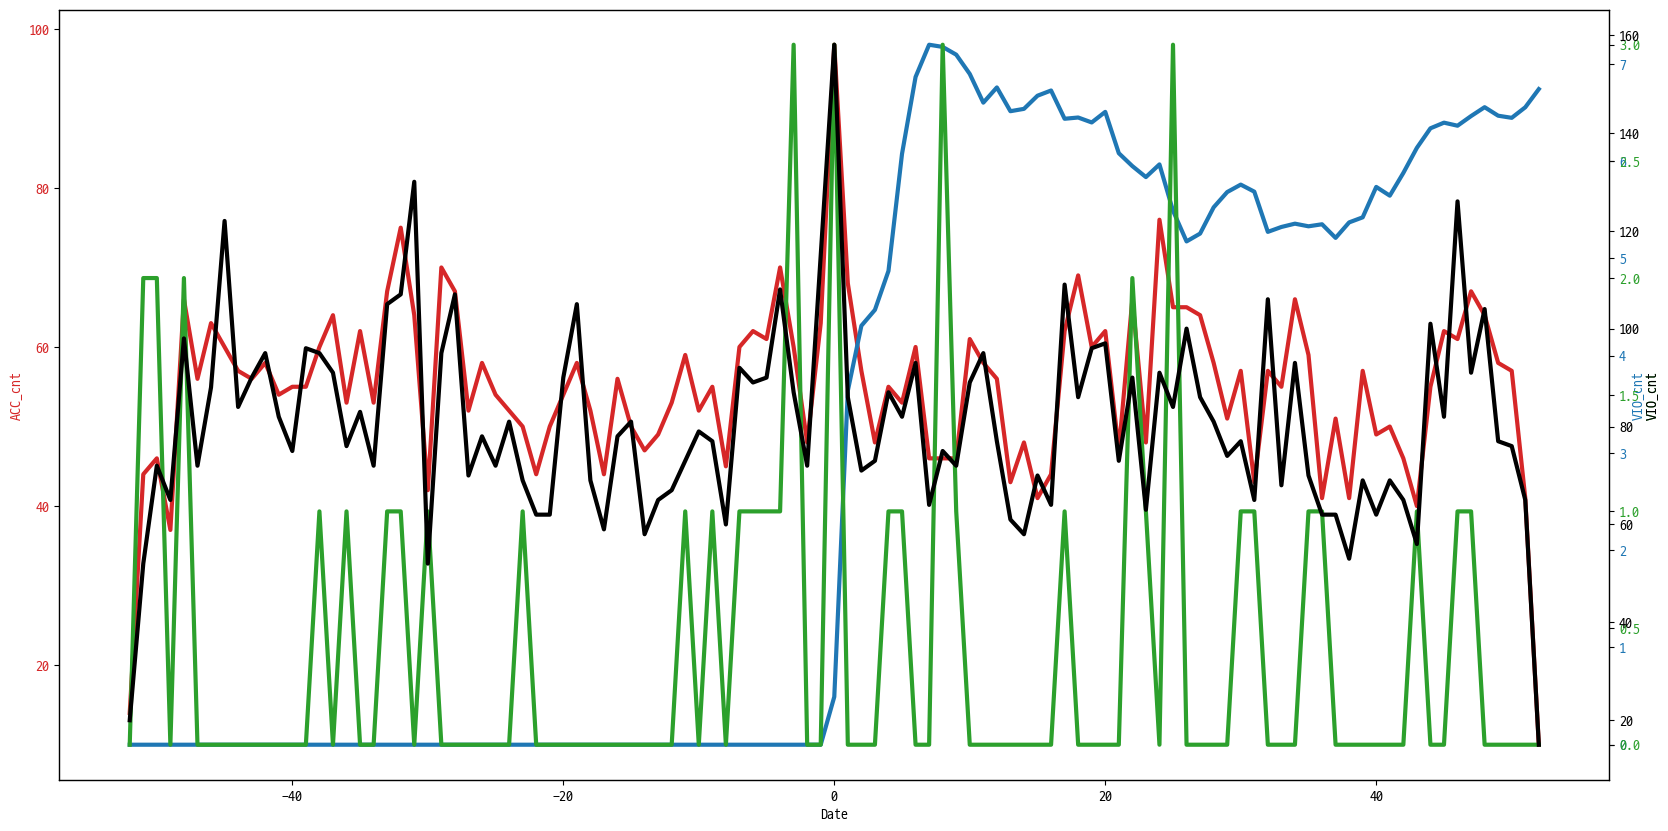

In [135]:
fig, ax1 = plt.subplots(figsize=(20,10))
tmp = df[df['장비고유구분'].isin(aft_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사망자수' :'sum','인명피해수_비사망':'sum'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x: int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사망자수' :'sum','인명피해수_비사망':'sum'})

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('ACC_cnt', color=color)
ax1.plot(tmp['설치경과일수'],tmp['사고건수'], color=color,linewidth=3)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # x 축을 공유하는 두 번째 축 생성

color = 'tab:blue'
ax2.set_ylabel('VIO_cnt', color=color)
ax2.plot(tmp['설치경과일수'], tmp['평균초과속도'], color=color,linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
color = 'tab:green'
ax3.set_ylabel('VIO_cnt', color=color)
ax3.plot(tmp['설치경과일수'], tmp['사망자수'], color=color,linewidth=3)
ax3.tick_params(axis='y', labelcolor=color)

ax4 = ax1.twinx()
color = 'black'
ax4.set_ylabel('VIO_cnt', color=color)
ax4.plot(tmp['설치경과일수'], tmp['인명피해수_비사망'], color=color,linewidth=3)
ax4.tick_params(axis='y', labelcolor=color)


tmp.corr()

### 사고건이 감소한 곳

,설치경과일수,사고건수,평균초과속도
설치경과일수,1.000000,-0.481140,0.860479
사고건수,-0.481140,1.000000,-0.601361
평균초과속도,0.860479,-0.601361,1.000000


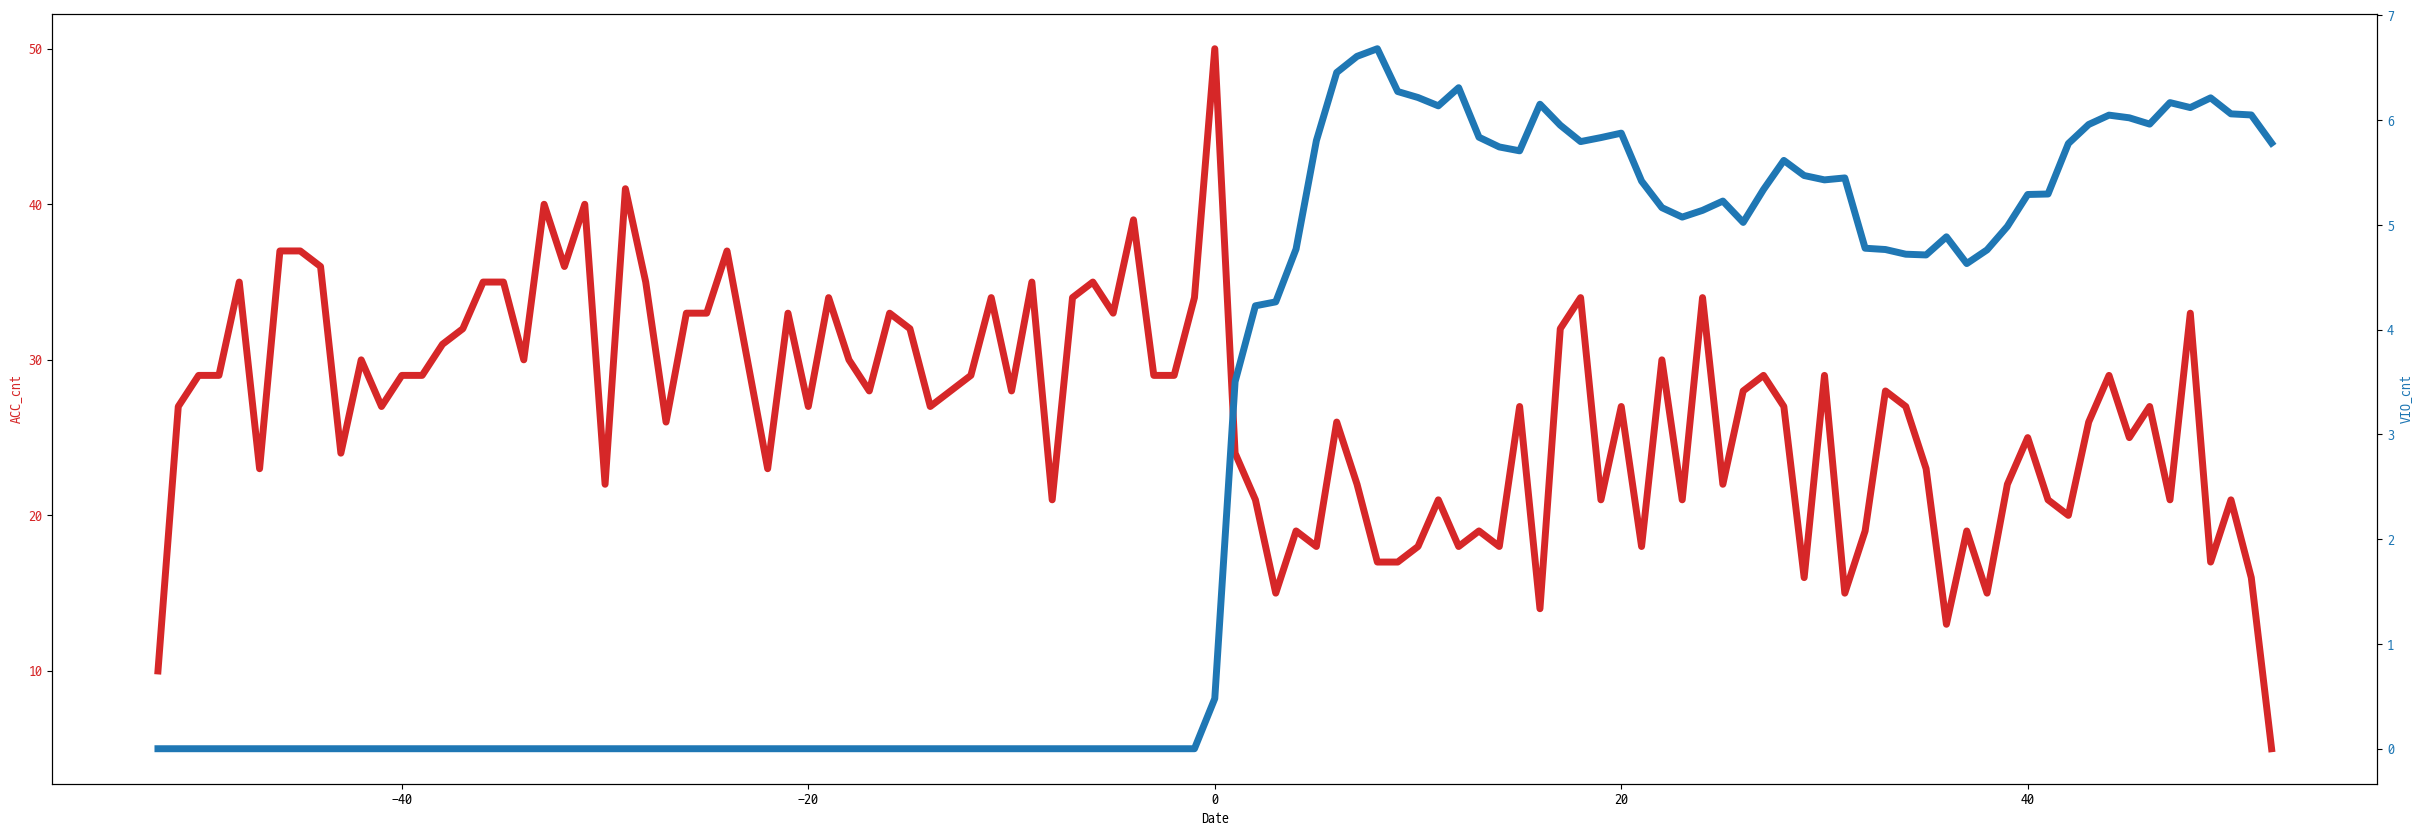

In [79]:
fig, ax1 = plt.subplots(figsize=(30,10))
tmp = df[df['장비고유구분'].isin(bef_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x: int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean'})

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('ACC_cnt', color=color)
ax1.plot(tmp['설치경과일수'],tmp['사고건수'], color=color,linewidth=5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # x 축을 공유하는 두 번째 축 생성

color = 'tab:blue'
ax2.set_ylabel('VIO_cnt', color=color)
ax2.plot(tmp['설치경과일수'], tmp['평균초과속도'], color=color,linewidth=5)
ax2.tick_params(axis='y', labelcolor=color)

tmp.corr()

## 초과속도가 변화한 곳

In [141]:
bef_list = []
aft_list = []
for i in tqdm(df['장비고유구분'].unique()):
    tmp = df[df['장비고유구분'] == i]
    bef = tmp[tmp['설치경과일수'] <= 182]
    aft = tmp[tmp['설치경과일수'] >= 183]
    if bef['평균초과속도'].mean() > aft['평균초과속도'].mean():
        bef_list.append(i)
    else:
        aft_list.append(i)

100%|█████████████████████████████████████████████████████████████████████████████████| 426/426 [00:11<00:00, 37.83it/s]


### 초과속도가 증가한 곳

,장비번호,장비종류,단속형태,납품업체,제조업체,제조번호,최초운영일자,장비규격,구간그룹명,지방청,자산구분,관리·설치일,설치구분/지자체명,관리종료일,종료구분,관리이관,설치(이전)회차,설치일자,설치장소,센터와의거리,관할서,제어기 위도,제어기 경도,표지판 위도,표지판 경도,표지판 개수,차량검지,설치·단속 차로수,도로차로수(편도),제한속도(소형),제한속도(대형),단속속도(소형),단속속도(대형),도로종류,노선번호,노선명,특정도로,도로유형,도로선형,조명장치
1363,G7334,신호위반,신호위반,아프로시스템즈,아프로시스템즈,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,부천시,NaN,NaN,NaN,1,2021-02-28,부천시 소사로794번길 51 오정초교 앞 어린이보호구역(오정동→부천제일시장),47.7,부천오정경찰서,37.527751,126.807251,37.527117,126.805242,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,소사로794번길,스쿨존,교차로,직선평지,LED
1364,G7335,신호위반,신호위반,아프로시스템즈,아프로시스템즈,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,부천시,NaN,NaN,NaN,1,2021-02-28,부천시 소사본동 159-51 소사초교 앞 사거리 어린이보호구역(시온고교→부천배드민턴...,41.2,부천소사경찰서,37.475259,126.797375,37.475273,126.799979,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,은성로,스쿨존,교차로,직선내리막,LED
1369,G7340,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,평택시,NaN,NaN,NaN,1,2021-02-28,평택시 세교동 571-1 세교초교 앞 어린이보호구역(개나리아파트->부영아파트),48.5,평택경찰서,37.002774,127.082966,37.001115,127.080984,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,세교공원로,스쿨존,교차로,직선평지,LED
1380,G7351,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,안산시,NaN,NaN,NaN,1,2021-02-28,안산시 상록구 충장로 663 시랑초교 정문 앞 어린이보호구역(순환로→시랑체육관),26.5,안산상록경찰서,37.336407,126.855301,37.336970,126.855775,2.0,레이다센서,2.0,2.0,30,30,41.0,41.0,시도,NaN,충장로,스쿨존,단일로,직선평지,LED
1381,G7352,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,안산시,NaN,NaN,NaN,1,2021-02-28,안산시 상록구 월피동 515-7 광덕초교 정문 앞 어린이보호구역(예술대학로→안산천서로),27.3,안산상록경찰서,37.333283,126.844540,37.334514,126.842154,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,광덕산로,스쿨존,단일로,직선내리막,LED
1385,G7356,신호위반,신호위반,토페스,토페스,NaN,2021-02-28,('17.03) -아,NaN,경기남부,지자체,2021-02-28,화성시,NaN,NaN,NaN,1,2021-02-28,화성시 정남면 신리 29-7 정남초교 정문 앞 어린이보호구역(정남파출소→신리사거리),17.9,화성동탄경찰서,37.167232,126.984106,37.171681,126.983394,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,만년로,스쿨존,단일로,직선평지,LED
1405,G7622,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-03-31,('17.03) -아,NaN,경기남부,지자체,2021-03-31,화성시,NaN,NaN,NaN,1,2021-03-31,화성시 향남읍 하길리 1487 발안농협하길지점 앞(부영9단지아파트→부영6단지아파트),30.6,화성서부경찰서,37.114085,126.912765,37.113328,126.915550,2.0,레이다센서,2.0,2.0,50,50,61.0,61.0,시도,NaN,상신하길로298번길,NaN,단일로,직선평지,LED
1432,G7649,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-03-31,('17.03) -아,NaN,경기남부,지자체,2021-03-31,안성시,NaN,NaN,NaN,1,2021-03-31,안성시 일죽면 신흥리 산 5 덕현교차로(국립이천호국원→일죽면행정복지센터),61.8,안성경찰서,37.121724,127.484854,37.131203,127.489667,2.0,레이다센서,2.0,2.0,60,60,71.0,71.0,지방도,329,노성로,NaN,교차로,직선평지,LED
1440,G7670,신호위반,신호위반,렉스젠,렉스젠,NaN,2021-03-31,('17.03) -아,NaN,경기남부,지자체,2021-03-31,부천시,NaN,NaN,NaN,1,2021-03-31,부천시 여월동 327 성곡초등학교 앞 어린이보호구역(서울→여월삼거리 ),42.9,부천오정경찰서,37.511755,126.805309,37.513013,126.812441,2.0,레이다센서,2.0,2.0,30,30,41.0,41.0,시도,NaN,여월로,스쿨존,교차로,직선평지,LED
1452,G8028,신호위반,신호위반,토페스,토페스,NaN,2021-04-30,('17.03) -아,NaN,경기남부,지자체,2021-04-30,수원시,NaN,NaN,NaN,1,2021-04-30,수원시 팔달구 화서동 273-5 화양초교삼거리 어린이보호구역(KT&G수원지사→화서오거리),4.7,수원중부경찰서,37.282863,126.996079,37.286791,126.993796,2.0,레이다센서,1.0,1.0,30,30,41.0,41.0,시도,NaN,화양로,스쿨존,교차로,직선평지,LED


,설치경과일수,사고건수,평균초과속도,사상자수,인명피해수_비사망
설치경과일수,1.000000,-0.237457,0.211608,-0.335750,-0.176529
사고건수,-0.237457,1.000000,-0.477140,0.537132,0.797261
평균초과속도,0.211608,-0.477140,1.000000,-0.207656,-0.365818
사상자수,-0.335750,0.537132,-0.207656,1.000000,0.247524
인명피해수_비사망,-0.176529,0.797261,-0.365818,0.247524,1.000000


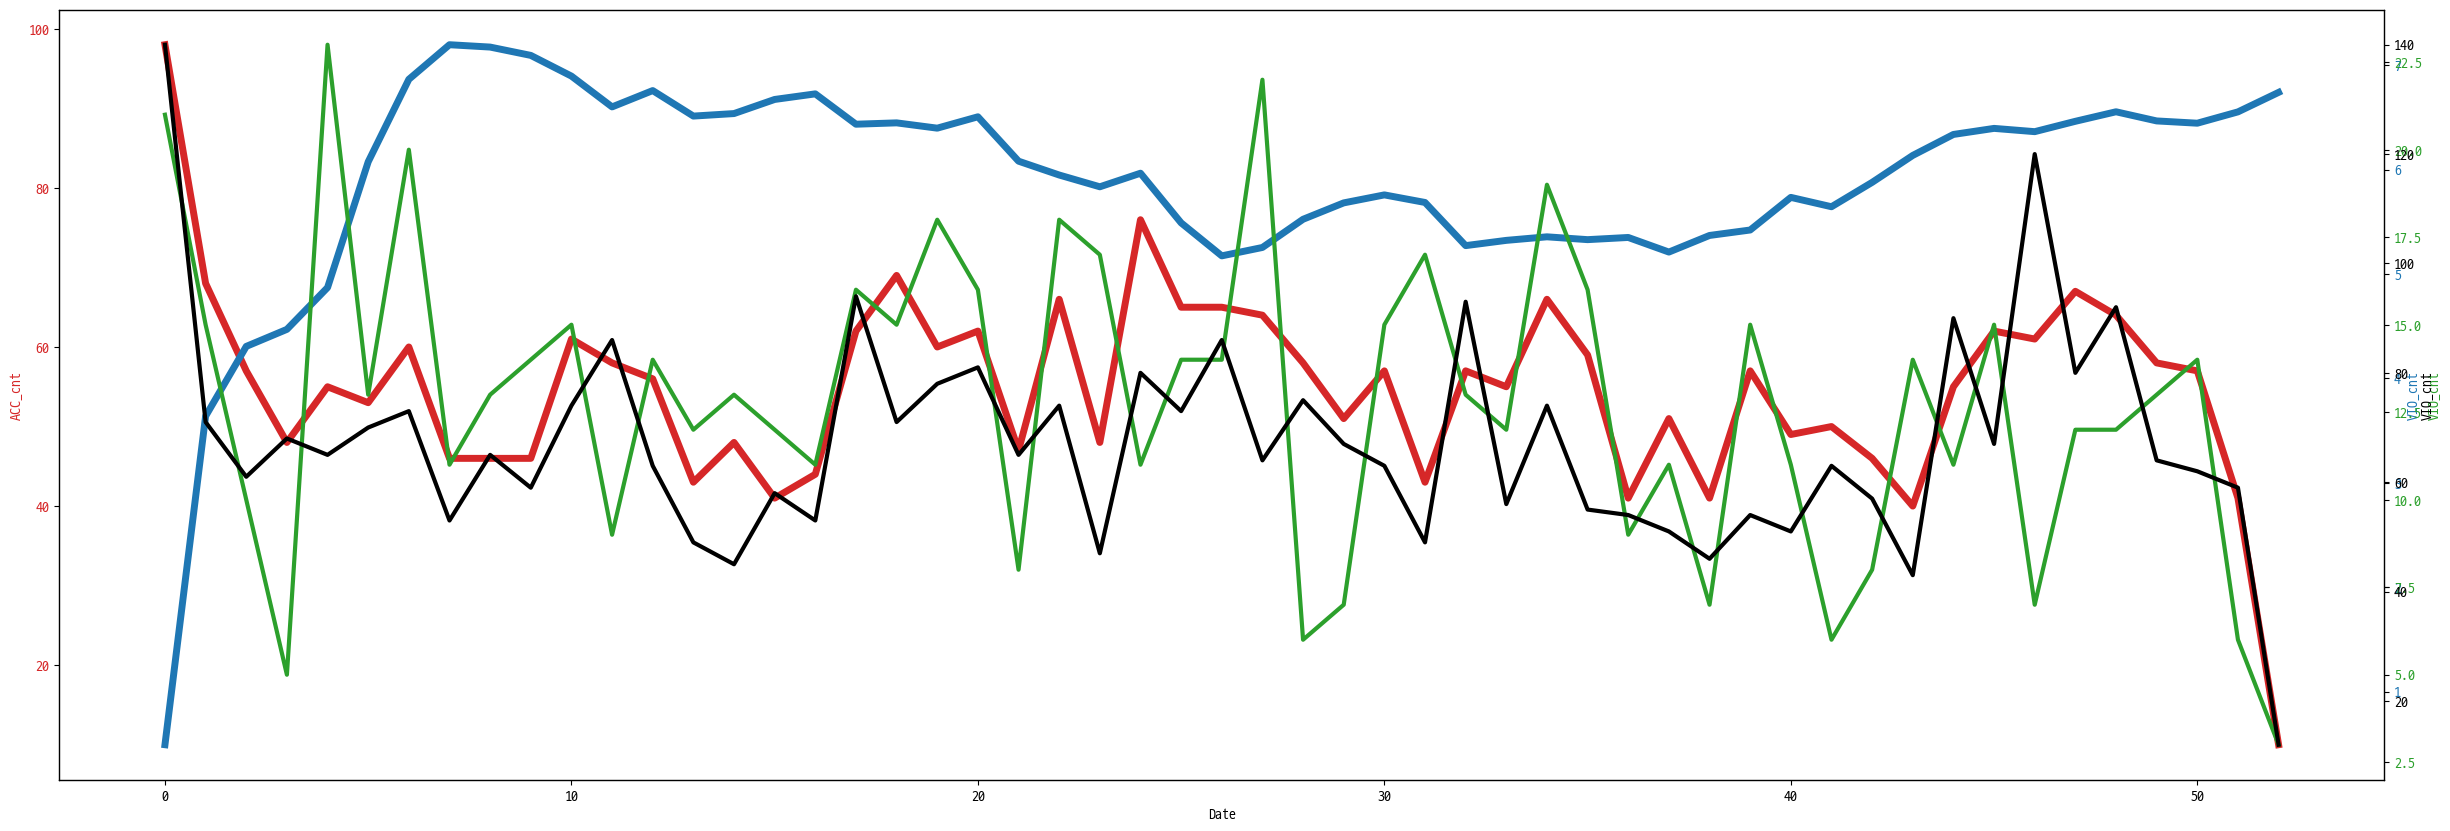

In [142]:
fig, ax1 = plt.subplots(figsize=(30,10))
tmp = df[df['장비고유구분'].isin(aft_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사상자수' :'sum','인명피해수_비사망':'sum'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x: int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사상자수' :'sum','인명피해수_비사망':'sum'})
tmp = tmp[tmp['설치경과일수'] >= 0]


color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('ACC_cnt', color=color)
ax1.plot(tmp['설치경과일수'],tmp['사고건수'], color=color,linewidth=5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # x 축을 공유하는 두 번째 축 생성

color = 'tab:blue'
ax2.set_ylabel('VIO_cnt', color=color)
ax2.plot(tmp['설치경과일수'], tmp['평균초과속도'], color=color,linewidth=5)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
color = 'tab:green'
ax3.set_ylabel('VIO_cnt', color=color)
ax3.plot(tmp['설치경과일수'], tmp['사상자수'], color=color,linewidth=3)
ax3.tick_params(axis='y', labelcolor=color)

ax4 = ax1.twinx()
color = 'black'
ax4.set_ylabel('VIO_cnt', color=color)
ax4.plot(tmp['설치경과일수'], tmp['인명피해수_비사망'], color=color,linewidth=3)
ax4.tick_params(axis='y', labelcolor=color)

tmp.corr()
#tmp.to_csv('./forvisual/after_speed.csv',index=False, encoding='cp949')

### 초과속도가 감소한 곳

,설치경과일수,사고건수,평균초과속도,사상자수,인명피해수_비사망
설치경과일수,1.000000,0.070258,-0.829840,0.160128,-0.010143
사고건수,0.070258,1.000000,-0.162125,0.555013,0.792758
평균초과속도,-0.829840,-0.162125,1.000000,-0.265597,0.006259
사상자수,0.160128,0.555013,-0.265597,1.000000,0.182471
인명피해수_비사망,-0.010143,0.792758,0.006259,0.182471,1.000000


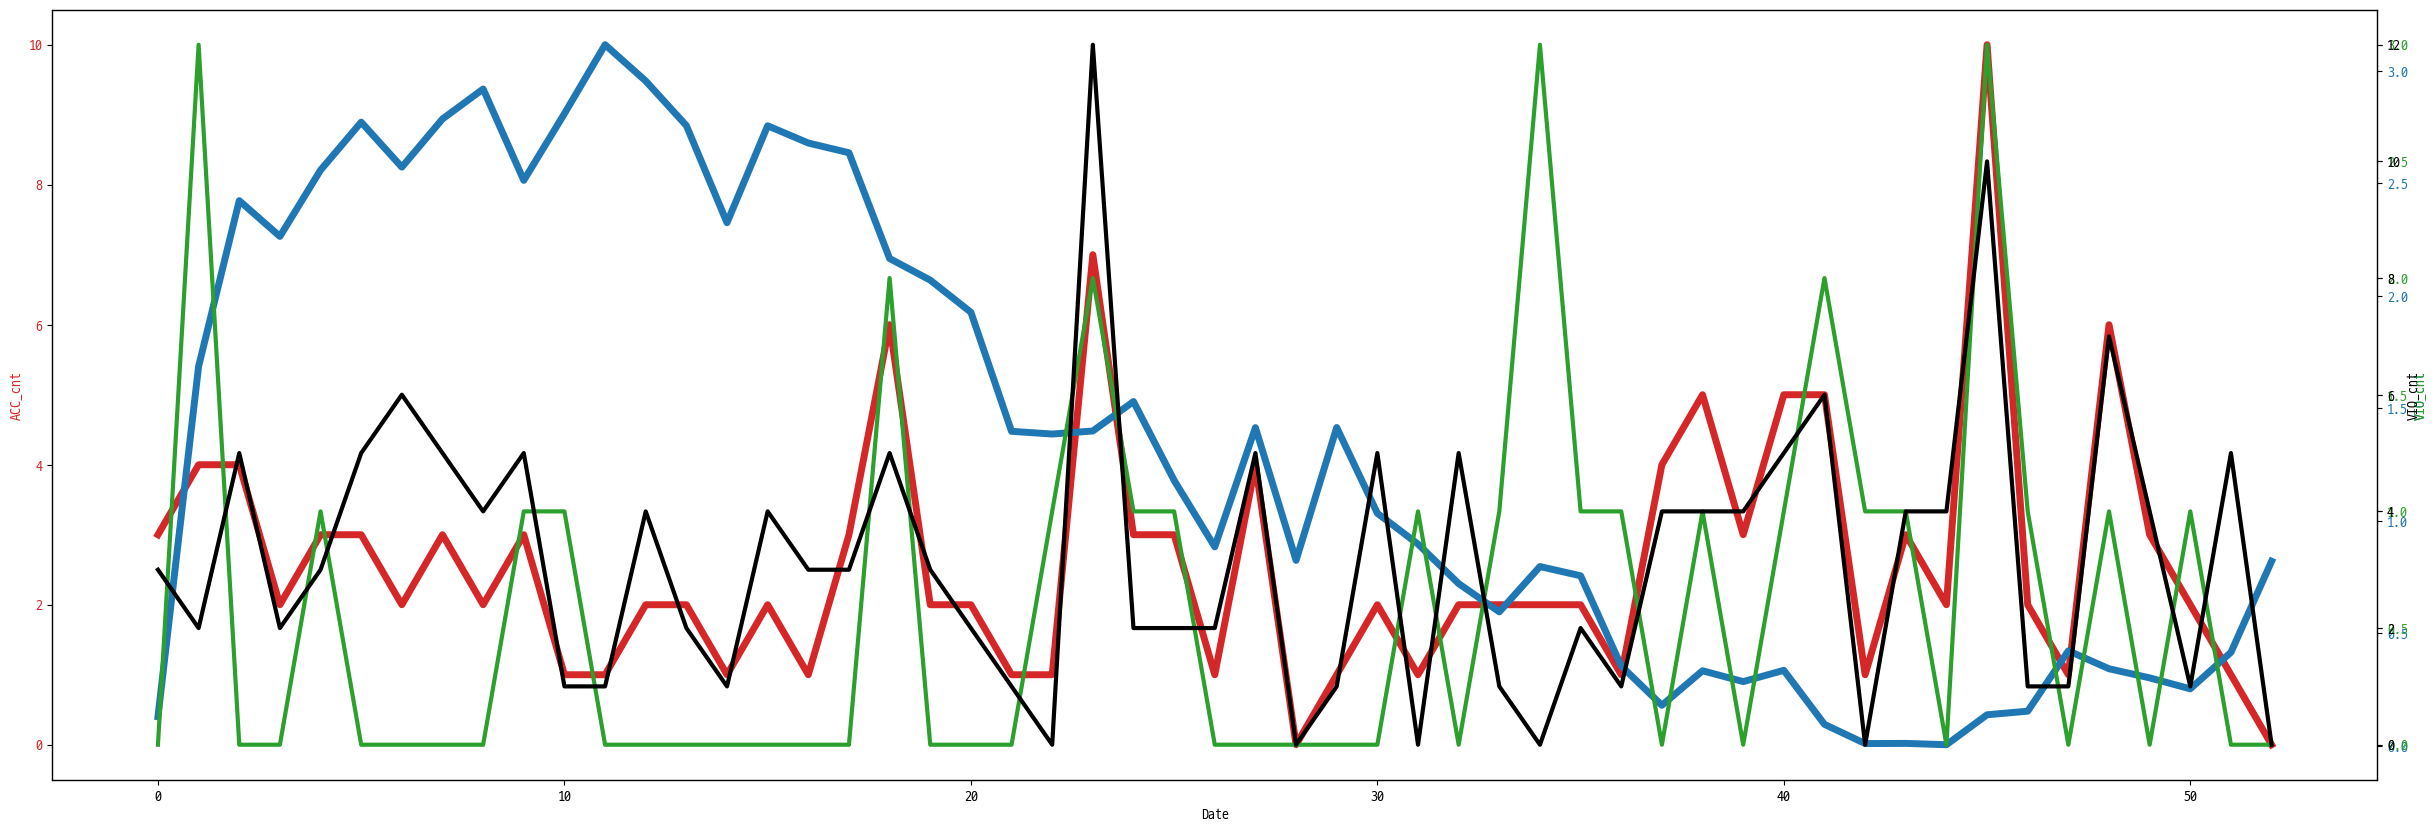

In [143]:
fig, ax1 = plt.subplots(figsize=(30,10))
tmp = df[df['장비고유구분'].isin(bef_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사상자수' :'sum','인명피해수_비사망':'sum'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x: int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수' : 'sum','평균초과속도' : 'mean','사상자수' :'sum','인명피해수_비사망':'sum'})
tmp = tmp[tmp['설치경과일수'] >= 0]


color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('ACC_cnt', color=color)
ax1.plot(tmp['설치경과일수'],tmp['사고건수'], color=color,linewidth=5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # x 축을 공유하는 두 번째 축 생성

color = 'tab:blue'
ax2.set_ylabel('VIO_cnt', color=color)
ax2.plot(tmp['설치경과일수'], tmp['평균초과속도'], color=color,linewidth=5)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
color = 'tab:green'
ax3.set_ylabel('VIO_cnt', color=color)
ax3.plot(tmp['설치경과일수'], tmp['사상자수'], color=color,linewidth=3)
ax3.tick_params(axis='y', labelcolor=color)

ax4 = ax1.twinx()
color = 'black'
ax4.set_ylabel('VIO_cnt', color=color)
ax4.plot(tmp['설치경과일수'], tmp['인명피해수_비사망'], color=color,linewidth=3)
ax4.tick_params(axis='y', labelcolor=color)

tmp.corr()
#tmp.to_csv('./forvisual/after_speed.csv',index=False, encoding='cp949')

In [224]:
acc = pd.read_csv('../use_data/result/mart/TB_ACC_RST_TRD_TRY.csv')
vio = pd.read_csv('../use_data/result/mart/TB_VIO_RST_TRD_TRY.csv')

In [225]:
acc = acc[acc['설치경과일수'] >= 0]
vio = vio[vio['설치경과일수'] >= 0]

In [237]:
acc['예측_사고건수평균'] = acc[[x for x in acc.columns if '_사고건수' in x]].mean(axis=1)

In [238]:
succ_list = []
fail_list = []
for i in tqdm(acc['장비고유구분'].unique()):
    tmp = acc[acc['장비고유구분'] == i]
    if tmp['사고건수'].mean() > tmp['예측_사고건수평균'].mean():
        fail_list.append(i)
    else:
        succ_list.append(i)

100%|█████████████████████████████████████████████████████████████████████████████████| 426/426 [00:06<00:00, 70.20it/s]


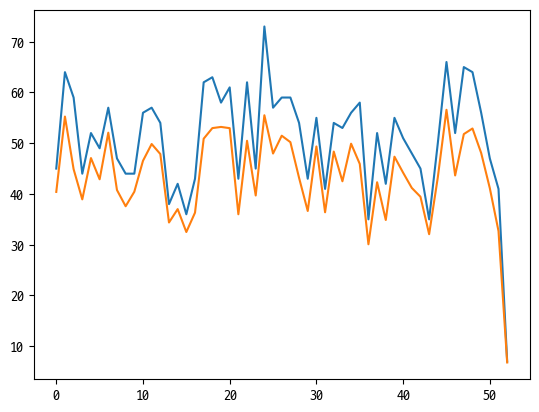

In [184]:
tmp = acc[acc['장비고유구분'].isin(fail_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수':'sum','예측_사고건수평균':'sum'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x : int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수':'sum','예측_사고건수평균':'sum'})
tmp.to_csv('./forvisual/acc_pred_fail.csv',index=False,encoding='cp949')
plt.plot(tmp['설치경과일수'], tmp['사고건수'])
plt.plot(tmp['설치경과일수'], tmp['예측_사고건수평균'])

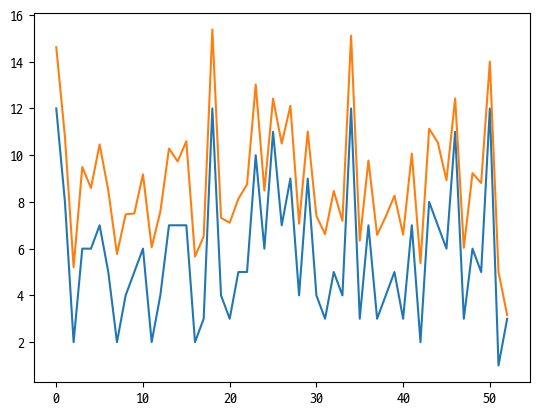

In [185]:
tmp = acc[acc['장비고유구분'].isin(succ_list)].groupby(['설치경과일수'],as_index=False).agg({'사고건수':'sum','예측_사고건수평균':'sum'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x : int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'사고건수':'sum','예측_사고건수평균':'sum'})
tmp.to_csv('./forvisual/acc_pred_succ.csv',index=False,encoding='cp949')
plt.plot(tmp['설치경과일수'], tmp['사고건수'])
plt.plot(tmp['설치경과일수'], tmp['예측_사고건수평균'])

In [177]:
fail_mts = mts[mts['장비번호'].isin(fail_list)]
succ_mts = mts[mts['장비번호'].isin(succ_list)]

In [241]:
mts.columns

Index(['장비번호', '장비종류', '단속형태', '납품업체', '제조업체', '제조번호', '최초운영일자', '장비규격',
       '구간그룹명', '지방청', '자산구분', '관리·설치일', '설치구분/지자체명', '관리종료일', '종료구분', '관리이관',
       '설치(이전)회차', '설치일자', '설치장소', '센터와의거리', '관할서', '제어기 위도', '제어기 경도',
       '표지판 위도', '표지판 경도', '표지판 개수', '차량검지', '설치·단속 차로수', '도로차로수(편도)',
       '제한속도(소형)', '제한속도(대형)', '단속속도(소형)', '단속속도(대형)', '도로종류', '노선번호', '노선명',
       '특정도로', '도로유형', '도로선형', '조명장치'],
      dtype='object')

In [242]:
for i in ['단속형태','설치구분/지자체명', '특정도로', '도로유형', '도로선형', '도로종류']:
    display(fail_mts[i].value_counts(normalize=True)*100)

단속형태
신호위반    57.142857
속도위반    42.857143
Name: proportion, dtype: float64

설치구분/지자체명
안성시    17.021277
안산시    17.021277
용인시    12.765957
화성시    10.638298
성남시    10.638298
부천시     8.510638
김포시     6.382979
수원시     4.255319
오산시     4.255319
광명시     2.127660
하남시     2.127660
시흥시     2.127660
양평군     2.127660
Name: proportion, dtype: float64

특정도로
스쿨존       85.714286
특정도로아님    12.244898
실버존        2.040816
Name: proportion, dtype: float64

도로유형
교차로    59.183673
단일로    40.816327
Name: proportion, dtype: float64

도로선형
직선평지     85.714286
직선내리막     6.122449
직선오르막     4.081633
좌내리막      2.040816
우내리막      2.040816
Name: proportion, dtype: float64

도로종류
시도      71.428571
지방도     20.408163
고속도로     4.081633
국도       4.081633
Name: proportion, dtype: float64

In [243]:
for i in ['단속형태','설치구분/지자체명', '특정도로', '도로유형', '도로선형', '도로종류' ]:
    display(succ_mts[i].value_counts(normalize=True)*100)

단속형태
신호위반    81.769437
속도위반    18.230563
Name: proportion, dtype: float64

설치구분/지자체명
화성시    16.119403
안산시    15.223881
용인시    14.626866
평택시     9.850746
부천시     6.865672
안성시     6.268657
김포시     6.268657
수원시     4.179104
여주시     3.283582
하남시     3.283582
성남시     2.985075
안양시     2.686567
군포시     1.791045
광주시     1.492537
시흥시     1.194030
이천시     0.895522
오산시     0.895522
양평군     0.895522
과천시     0.895522
의왕시     0.298507
Name: proportion, dtype: float64

특정도로
스쿨존       56.032172
특정도로아님    43.163539
실버존        0.804290
Name: proportion, dtype: float64

도로유형
교차로    74.530831
단일로    25.469169
Name: proportion, dtype: float64

도로선형
직선평지     82.037534
직선내리막     8.042895
좌내리막      3.217158
좌평지       2.144772
우평지       2.144772
직선오르막     1.340483
우내리막      0.536193
우오르막      0.268097
좌오르막      0.268097
Name: proportion, dtype: float64

도로종류
시도      73.190349
지방도     16.621984
국도       9.919571
고속도로     0.268097
Name: proportion, dtype: float64

In [244]:
vio['예측_평균초과속도'] = vio[[x for x in vio.columns if '_초과속도' in x]].mean(axis=1)

In [245]:
succ_list = []
fail_list = []
for i in tqdm(vio['장비고유구분'].unique()):
    tmp = vio[vio['장비고유구분'] == i]
    if tmp['평균초과속도'].mean() > tmp['예측_평균초과속도'].mean():
        fail_list.append(i)
    else:
        succ_list.append(i)

100%|█████████████████████████████████████████████████████████████████████████████████| 426/426 [00:06<00:00, 63.30it/s]


In [247]:
succ_list

['G6950',
 'G6951',
 'G6952',
 'G6953',
 'G6954',
 'G6955',
 'G6956',
 'G6957',
 'G6958',
 'G6959',
 'G6960',
 'G6961',
 'G6962',
 'G6963',
 'G6964',
 'G6965',
 'G6966',
 'G6967',
 'G6968',
 'G6969',
 'G6970',
 'G6971',
 'G6972',
 'G6973',
 'G6974',
 'G6975',
 'G6976',
 'G6977',
 'G6978',
 'G6979',
 'G6980',
 'G6981',
 'G6982',
 'G6983',
 'G6984',
 'G6985',
 'G6986',
 'G6987',
 'G7334',
 'G7335',
 'G7336',
 'G7337',
 'G7338',
 'G7339',
 'G7340',
 'G7341',
 'G7342',
 'G7343',
 'G7344',
 'G7345',
 'G7346',
 'G7347',
 'G7348',
 'G7349',
 'G7350',
 'G7351',
 'G7352',
 'G7353',
 'G7354',
 'G7355',
 'G7356',
 'G7357',
 'G7358',
 'G7359',
 'G7360',
 'G7607',
 'G7608',
 'G7609',
 'G7610',
 'G7611',
 'G7612',
 'G7613',
 'G7614',
 'G7615',
 'G7616',
 'G7617',
 'G7618',
 'G7619',
 'G7620',
 'G7622',
 'G7623',
 'G7624',
 'G7625',
 'G7627',
 'G7629',
 'G7630',
 'G7631',
 'G7632',
 'G7633',
 'G7634',
 'G7635',
 'G7636',
 'G7637',
 'G7638',
 'G7639',
 'G7640',
 'G7641',
 'G7642',
 'G7643',
 'G7644',


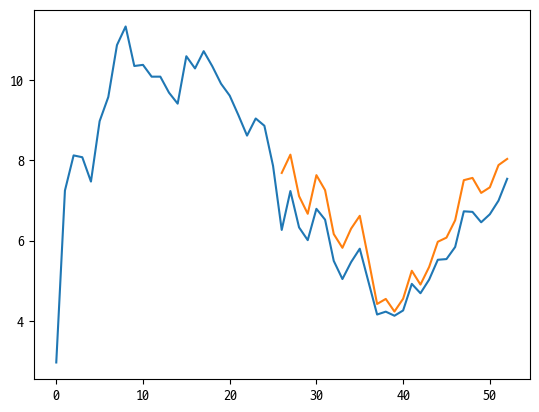

In [229]:
tmp = vio[vio['장비고유구분'].isin(fail_list)].groupby(['설치경과일수'],as_index=False).agg({'평균초과속도':'mean','예측_평균초과속도':'mean'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x : int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'평균초과속도':'mean','예측_평균초과속도':'mean'})
tmp.to_csv('./forvisual/vio_pred_fail.csv',index=False,encoding='cp949')
plt.plot(tmp['설치경과일수'], tmp['평균초과속도'])
plt.plot(tmp['설치경과일수'], tmp['예측_평균초과속도'])

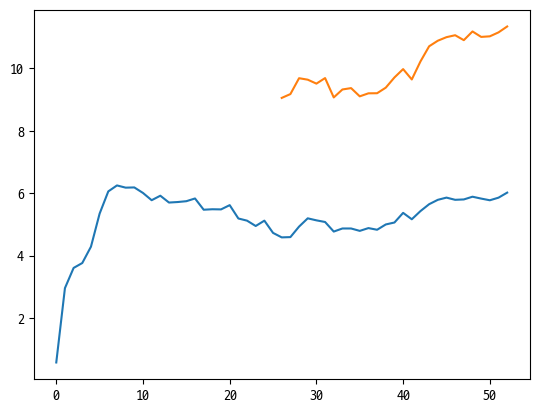

In [230]:
tmp = vio[vio['장비고유구분'].isin(succ_list)].groupby(['설치경과일수'],as_index=False).agg({'평균초과속도':'mean','예측_평균초과속도':'mean'})
tmp['설치경과일수'] = tmp['설치경과일수'].apply(lambda x : int(x/7))
tmp = tmp.groupby(['설치경과일수'],as_index=False).agg({'평균초과속도':'mean','예측_평균초과속도':'mean'})
tmp.to_csv('./forvisual/vio_pred_succ.csv',index=False,encoding='cp949')
plt.plot(tmp['설치경과일수'], tmp['평균초과속도'])
plt.plot(tmp['설치경과일수'], tmp['예측_평균초과속도'])

In [250]:
succ_list

['G6950',
 'G6951',
 'G6952',
 'G6953',
 'G6954',
 'G6955',
 'G6956',
 'G6957',
 'G6958',
 'G6959',
 'G6960',
 'G6961',
 'G6962',
 'G6963',
 'G6964',
 'G6965',
 'G6966',
 'G6967',
 'G6968',
 'G6969',
 'G6970',
 'G6971',
 'G6972',
 'G6973',
 'G6974',
 'G6975',
 'G6976',
 'G6977',
 'G6978',
 'G6979',
 'G6980',
 'G6981',
 'G6982',
 'G6983',
 'G6984',
 'G6985',
 'G6986',
 'G6987',
 'G7334',
 'G7335',
 'G7336',
 'G7337',
 'G7338',
 'G7339',
 'G7340',
 'G7341',
 'G7342',
 'G7343',
 'G7344',
 'G7345',
 'G7346',
 'G7347',
 'G7348',
 'G7349',
 'G7350',
 'G7351',
 'G7352',
 'G7353',
 'G7354',
 'G7355',
 'G7356',
 'G7357',
 'G7358',
 'G7359',
 'G7360',
 'G7607',
 'G7608',
 'G7609',
 'G7610',
 'G7611',
 'G7612',
 'G7613',
 'G7614',
 'G7615',
 'G7616',
 'G7617',
 'G7618',
 'G7619',
 'G7620',
 'G7622',
 'G7623',
 'G7624',
 'G7625',
 'G7627',
 'G7629',
 'G7630',
 'G7631',
 'G7632',
 'G7633',
 'G7634',
 'G7635',
 'G7636',
 'G7637',
 'G7638',
 'G7639',
 'G7640',
 'G7641',
 'G7642',
 'G7643',
 'G7644',


In [232]:
fail_mts = mts[mts['장비번호'].isin(fail_list)]
succ_mts = mts[mts['장비번호'].isin(succ_list)]

In [248]:
for i in ['단속형태','설치구분/지자체명', '특정도로', '도로유형', '도로선형', '도로종류']:
    display(fail_mts[i].value_counts(normalize=True)*100)

단속형태
신호위반    57.142857
속도위반    42.857143
Name: proportion, dtype: float64

설치구분/지자체명
안성시    17.021277
안산시    17.021277
용인시    12.765957
화성시    10.638298
성남시    10.638298
부천시     8.510638
김포시     6.382979
수원시     4.255319
오산시     4.255319
광명시     2.127660
하남시     2.127660
시흥시     2.127660
양평군     2.127660
Name: proportion, dtype: float64

특정도로
스쿨존       85.714286
특정도로아님    12.244898
실버존        2.040816
Name: proportion, dtype: float64

도로유형
교차로    59.183673
단일로    40.816327
Name: proportion, dtype: float64

도로선형
직선평지     85.714286
직선내리막     6.122449
직선오르막     4.081633
좌내리막      2.040816
우내리막      2.040816
Name: proportion, dtype: float64

도로종류
시도      71.428571
지방도     20.408163
고속도로     4.081633
국도       4.081633
Name: proportion, dtype: float64

In [249]:
for i in ['단속형태','설치구분/지자체명', '특정도로', '도로유형', '도로선형','도로종류' ]:
    display(succ_mts[i].value_counts(normalize=True)*100)

단속형태
신호위반    81.769437
속도위반    18.230563
Name: proportion, dtype: float64

설치구분/지자체명
화성시    16.119403
안산시    15.223881
용인시    14.626866
평택시     9.850746
부천시     6.865672
안성시     6.268657
김포시     6.268657
수원시     4.179104
여주시     3.283582
하남시     3.283582
성남시     2.985075
안양시     2.686567
군포시     1.791045
광주시     1.492537
시흥시     1.194030
이천시     0.895522
오산시     0.895522
양평군     0.895522
과천시     0.895522
의왕시     0.298507
Name: proportion, dtype: float64

특정도로
스쿨존       56.032172
특정도로아님    43.163539
실버존        0.804290
Name: proportion, dtype: float64

도로유형
교차로    74.530831
단일로    25.469169
Name: proportion, dtype: float64

도로선형
직선평지     82.037534
직선내리막     8.042895
좌내리막      3.217158
좌평지       2.144772
우평지       2.144772
직선오르막     1.340483
우내리막      0.536193
우오르막      0.268097
좌오르막      0.268097
Name: proportion, dtype: float64

도로종류
시도      73.190349
지방도     16.621984
국도       9.919571
고속도로     0.268097
Name: proportion, dtype: float64

In [4]:
df

,기준일자,장비고유구분,단속형태,설치지역,기상관측지역,기준연월,사고건수,사망자수,중상자수,경상자수,부상신고자수,관련차량대수,평균발생시각,단속건수,제한속도,평균과속속도,평균초과속도,일평균기온,일최저기온,일최고기온,일강수량,일최대순간풍속,일평균풍속,일평균상대습도,일평균중기압,장비설치지역_주민등록인구수,장비설치지역_차량등록대수,장비설치일자,설치경과일수,도로종류,구간유형,도로유형,도로선형
0,2020-02-01,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,1.4,-4.2,7.1,0.0,6.1,1.0,83.4,5.6,111008,68784,2021-01-31,-365,시도,일반구역,단일로,직선평지
1,2020-02-02,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,1.1,-3.1,6.5,0.0,4.0,0.9,73.3,4.7,111008,68784,2021-01-31,-364,시도,일반구역,단일로,직선평지
2,2020-02-03,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,0.3,-3.7,5.1,0.0,8.7,1.9,56.5,3.5,111008,68784,2021-01-31,-363,시도,일반구역,단일로,직선평지
3,2020-02-04,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,-1.2,-8.7,5.9,1.7,7.8,1.5,70.8,3.9,111008,68784,2021-01-31,-362,시도,일반구역,단일로,직선평지
4,2020-02-05,G6950,속도위반,여주시,이천,2020년02월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000000,0.000000,-6.5,-9.5,-2.0,0.0,7.7,1.8,42.9,1.6,111008,68784,2021-01-31,-361,시도,일반구역,단일로,직선평지
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310975,2022-08-20,경부하행,구간과속,오산시,수원,2022년08월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,110,137.666667,27.666667,27.3,24.5,30.8,0.0,6.8,2.1,84.5,30.3,230142,114827,2021-08-25,360,고속도로,일반구역,단일로,직선평지
310976,2022-08-21,경부하행,구간과속,오산시,수원,2022년08월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,110,140.086957,30.086957,27.4,23.7,33.0,0.0,6.5,1.3,80.9,28.9,230142,114827,2021-08-25,361,고속도로,일반구역,단일로,직선평지
310977,2022-08-22,경부하행,구간과속,오산시,수원,2022년08월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,110,135.866667,25.866667,26.4,21.9,30.9,2.2,6.0,1.5,81.4,27.4,230142,114827,2021-08-25,362,고속도로,일반구역,단일로,직선평지
310978,2022-08-23,경부하행,구간과속,오산시,수원,2022년08월,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,110,135.923077,25.923077,24.9,21.2,29.9,6.1,5.0,1.3,83.4,25.9,230142,114827,2021-08-25,363,고속도로,일반구역,단일로,직선평지


In [17]:
import numpy as np
import seaborn as sns

findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub Dotum Medium' not found.
findfont: Font family 'KoPub

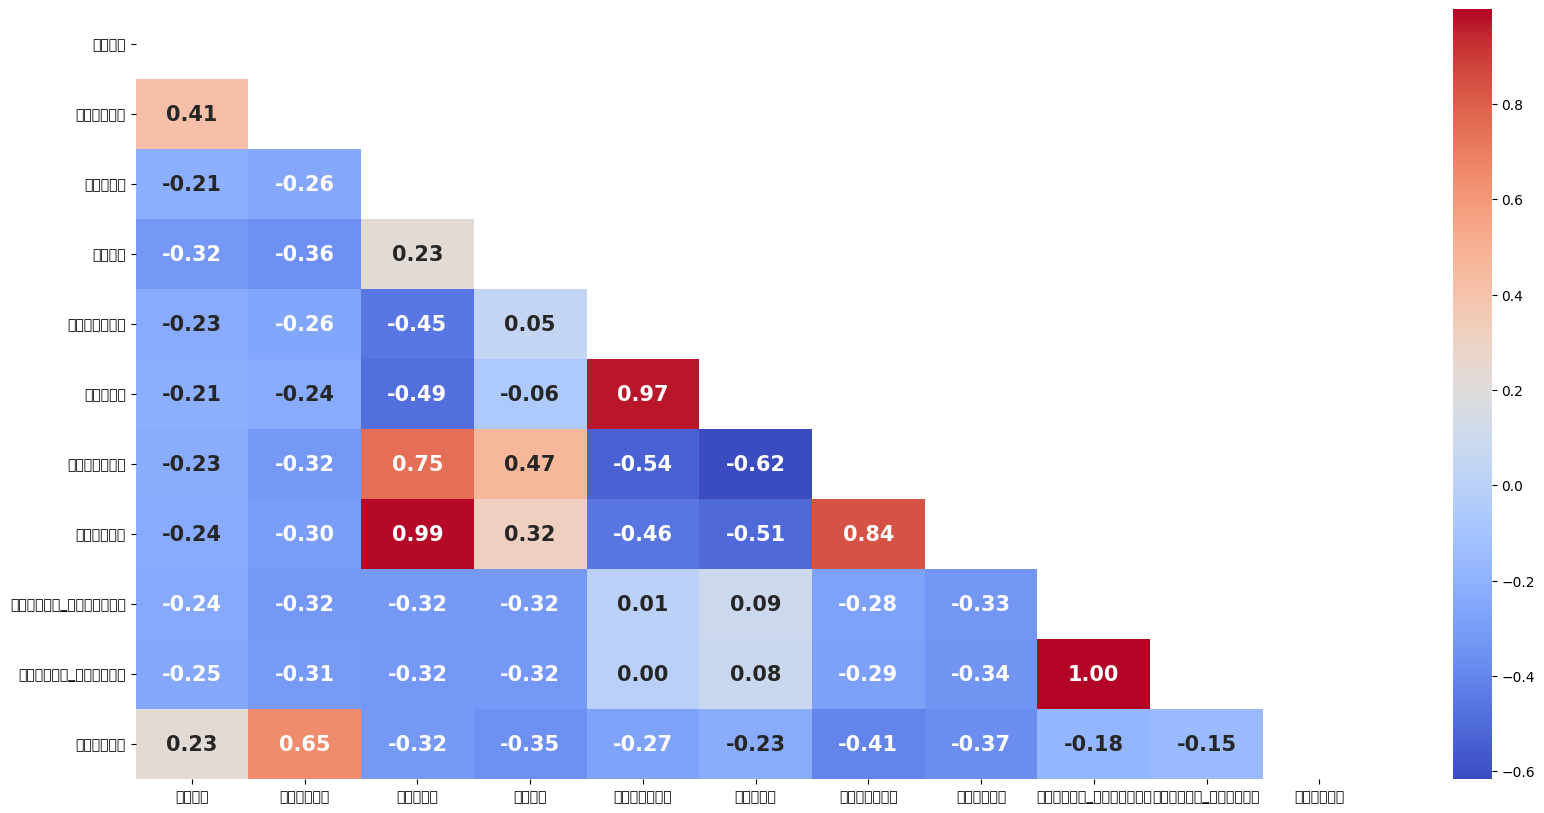

In [39]:
tmp = df[['단속건수', '평균초과속도', '일평균기온','일강수량', '일최대순간풍속', '일평균풍속',
       '일평균상대습도', '일평균중기압', '장비설치지역_주민등록인구수', '장비설치지역_차량등록대수','설치경과일수']].corr()
def prettyCorr(x, width=15, height=7):
    
    plt.figure(figsize=(width, height))
    mask = np.zeros_like(x.corr(), dtype= np.bool_)
    mask[np.triu_indices_from(mask)] = True
    annot_kws = {"size": 15, 'weight' : 'bold'}
    sns.heatmap(x.corr(), annot=True, fmt='.2f', mask=mask, cmap='coolwarm',annot_kws=annot_kws)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.show()

prettyCorr(tmp,20,10)

In [28]:
import matplotlib as mpl
print(mpl.get_cachedir())

/home/zokr/.local/lib/python3.8/site-packages/matplotlib/mpl-data/matplotlibrc


In [33]:
import matplotlib.pyplot as plt

# 폰트 파일 경로
font_path = '/Library/Fonts/YourFont.ttf'
font_name = plt.matplotlib.font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
출처: https://simon-yoon.tistory.com/149 [Simon Yoon's blog:티스토리]

/home/zokr/.cache/matplotlib


In [35]:
import matplotlib
print(matplotlib.get_cachedir())


/home/zokr/.cache/matplotlib


In [36]:
mpl.get_configdir()

'/home/zokr/.config/matplotlib'

In [37]:
print(mpl.rcParams['font.family'])
print(mpl.rcParams['font.size'])

['D2Coding']
10.0


In [57]:
mpl.rcParams['font.family'] = 'D2Coding'

In [40]:
%matplotlib inline

In [55]:
import platform
platform.platform()

import sys
sys.version_info

sys.version_info(major=3, minor=8, micro=10, releaselevel='final', serial=0)

In [56]:
import matplotlib

print ('버전: ', matplotlib.__version__)
print ('설치위치: ', matplotlib.__file__)
print ('설정: ', matplotlib.get_configdir())
print ('캐시: ', matplotlib.get_cachedir())

버전:  3.7.1
설치위치:  /home/zokr/.local/lib/python3.8/site-packages/matplotlib/__init__.py
설정:  /home/zokr/.config/matplotlib
캐시:  /home/zokr/.cache/matplotlib


In [60]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

<Axes: xlabel='평균초과속도', ylabel='장비설치지역_주민등록인구수'>

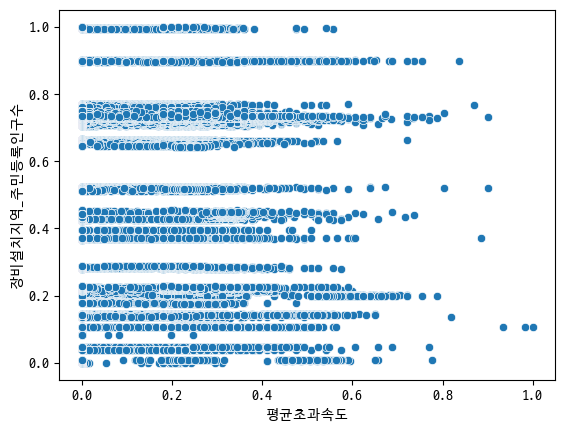

In [77]:
col = ['평균초과속도','장비설치지역_주민등록인구수']
tmp = df[df['설치경과일수'] >= 0][col]

tmp = StandardScaler().fit_transform(tmp)
tmp = MinMaxScaler().fit_transform(tmp)
tmp = pd.DataFrame(tmp,columns=col)

sns.scatterplot(data=tmp, x = tmp.columns[0], y= tmp.columns[1])